In [1]:
# 1. 导入库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号
# 1. 导入库
df=pd.read_csv("data/house_sales.csv")
df.info()
len(df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   city        106118 non-null  object
 1   address     104452 non-null  object
 2   area        105324 non-null  object
 3   floor       104024 non-null  object
 4   name        105564 non-null  object
 5   price       105564 non-null  object
 6   province    106118 non-null  object
 7   rooms       104036 non-null  object
 8   toward      105240 non-null  object
 9   unit        105564 non-null  object
 10  year        57736 non-null   object
 11  origin_url  105564 non-null  object
dtypes: object(12)
memory usage: 9.7+ MB


106118

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   city        106118 non-null  object
 1   address     104452 non-null  object
 2   area        105324 non-null  object
 3   floor       104024 non-null  object
 4   name        105564 non-null  object
 5   price       105564 non-null  object
 6   province    106118 non-null  object
 7   rooms       104036 non-null  object
 8   toward      105240 non-null  object
 9   unit        105564 non-null  object
 10  year        57736 non-null   object
 11  origin_url  105564 non-null  object
dtypes: object(12)
memory usage: 9.7+ MB
数据概览
总记录数： 106118
字段数量： 12
前5行数据：
city            0
address      1666
area          794
floor        2094
name          554
price         554
province        0
rooms        2082
toward        878
unit          554
year        48382
dtype: int64
city        0
address     0
a

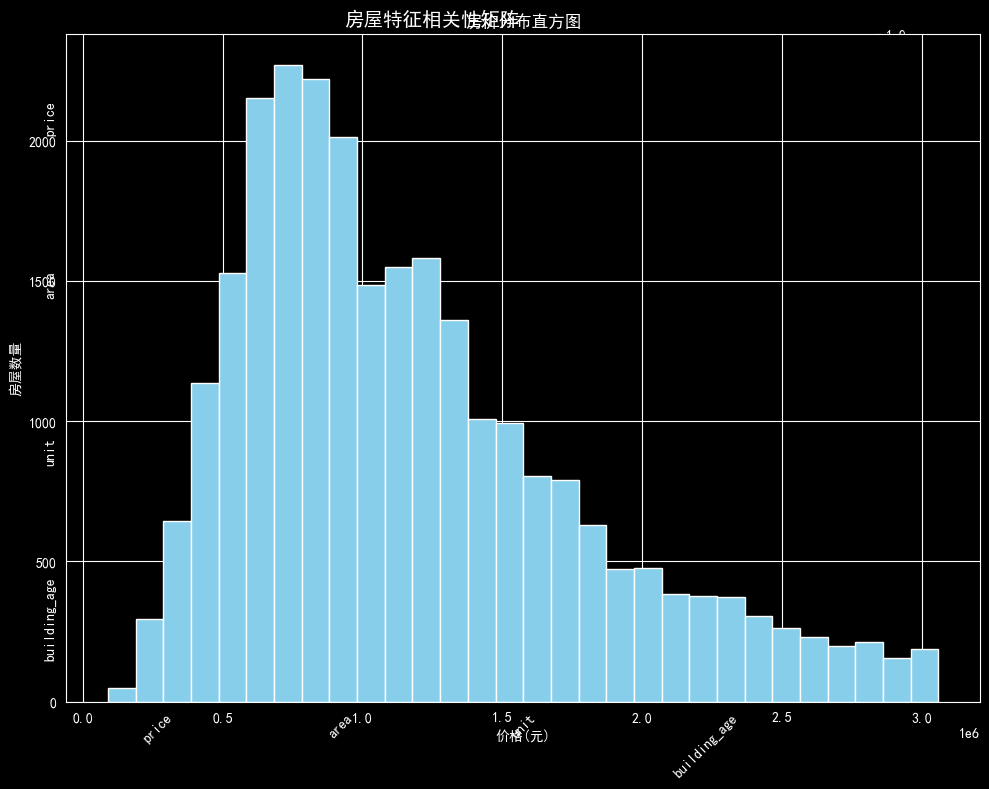


各城市房价统计:


price                           unit         
              mean     median count          mean   median
city                                                      
深圳    2.507692e+06  2660000.0    13  47923.307692  42190.0
桐庐    1.901240e+06  2018500.0    50  28016.580000  25556.5
淳安    2.061067e+06  2080000.0    45  27942.377778  29563.0
上海    1.847944e+06  2070000.0    54  27447.703704  27319.5
蓟州    1.903222e+06  1785000.0    72  25995.027778  22035.5
杭州    1.919100e+06  2000000.0    40  25972.125000  23239.5
厦门    2.012647e+06  2090000.0    17  25074.705882  26018.0
福州    1.894522e+06  1910000.0    46  24693.673913  22180.5
建德    1.719405e+06  1570000.0    42  24198.714286  24398.0
苏州    2.107931e+06  2125000.0    72  24088.111111  22797.5

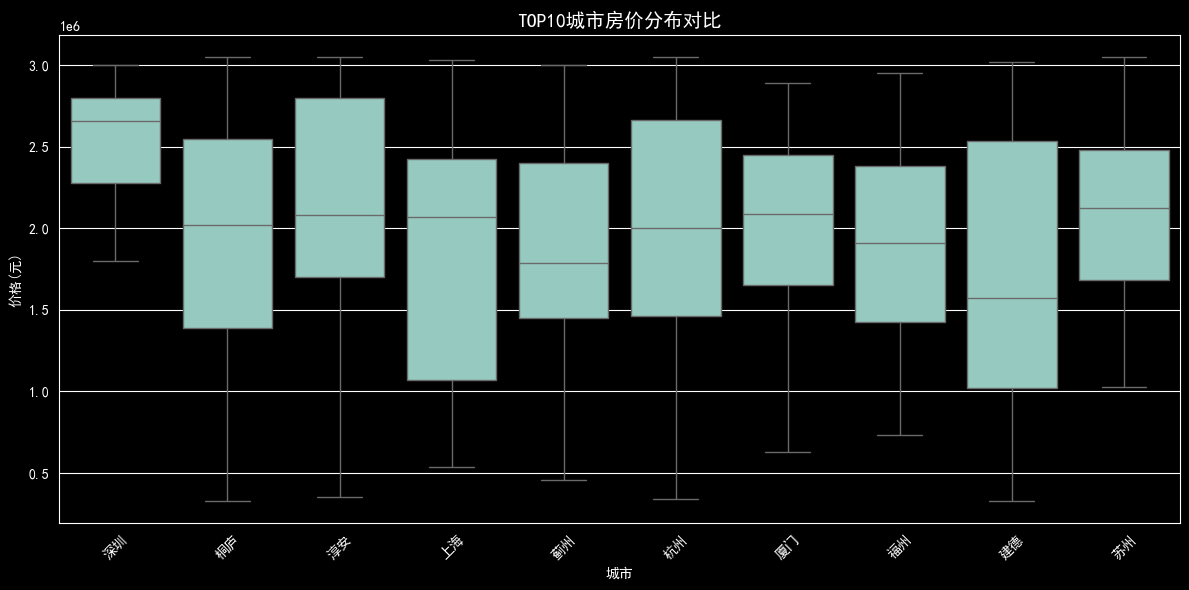


各朝向价格表现:


C:\Users\1\AppData\Local\Temp\ipykernel_19596\3291856753.py:210: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  toward_stats = df_toward.groupby('toward').agg({


price                unit building_age
                mean     median   median         mean
toward                                               
西南向     1.397118e+06  1384000.0  13333.0    13.452756
西向      1.026627e+06   860000.0  12528.0    13.385093
西北向     1.191083e+06  1050000.0  12290.0    13.473684
东北向     1.145552e+06  1000000.0  12198.0    12.609524
北向      9.252829e+05   755000.0  11698.0    13.108527
东向      1.101592e+06   950000.0  11421.0    12.761337
东南向     1.155426e+06  1050000.0  10864.0    10.951745
南向      1.145551e+06  1030000.0  10759.0    11.551160
南北向     1.194722e+06  1045000.0  10000.0    12.073703
东西向     9.893510e+05   820000.0   9000.0    15.490066

C:\Users\1\AppData\Local\Temp\ipykernel_19596\3291856753.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['unit'].values for name, group in df_toward.groupby('toward')]


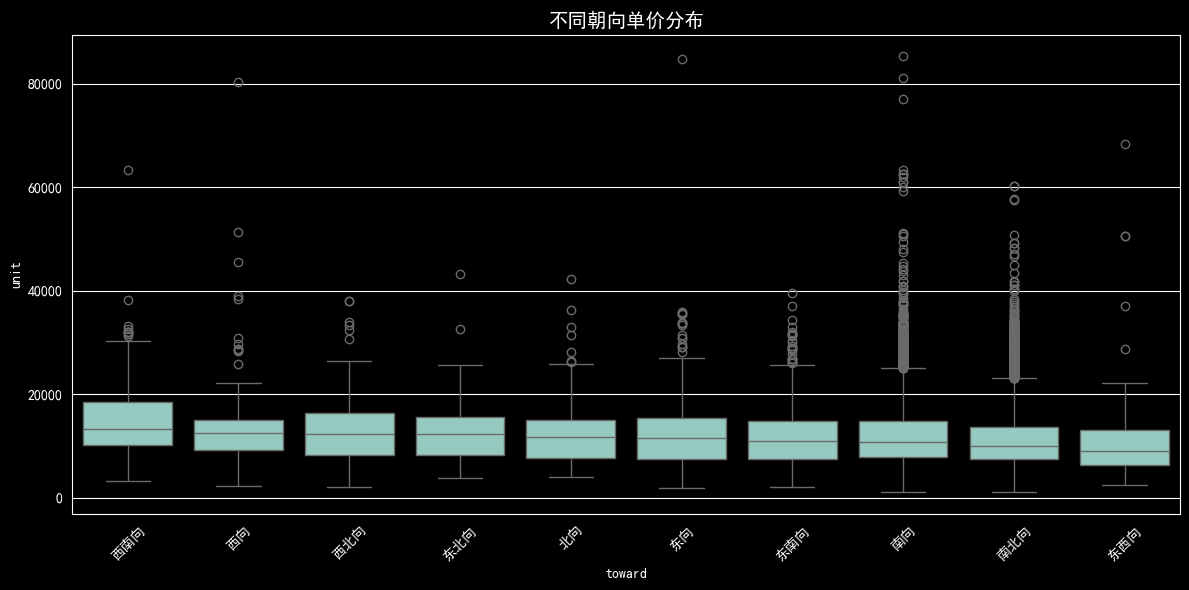

In [4]:

# 1. 导入库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号
# 2. 导入数据
df = pd.read_csv('data/house_sales.csv')
df.info()
len(df)

# 3. 数据概览
print('数据概览')
print('总记录数：',len(df))
print('字段数量：',len(df.columns))
print('前5行数据：')
df.head(5)

# 4. 数据清洗
# 删除无用的数据列
df.drop(columns='origin_url',inplace=True)

# 缺失值检查
print(df.isnull().sum())
# 删除缺失值数据
df.dropna(inplace=True)
# 缺失值检查
print(df.isnull().sum())

# 处理重复值
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

print(len(df))

# 数据类型的转换
# 价格处理（示例："128万" "$128"-> 1280000）
df['price'] = df['price'].astype(str).str.replace('万', '')
df['price'] = df['price'].astype(str).str.replace('$', '').astype(float).round(1) * 10000

# 面积处理（示例："90㎡" -> 90）
df['area'] = df['area'].astype(str).str.replace('㎡','').astype(float).round(1)

# 单价处理
df['unit'] = df['unit'].astype(str).str.replace('元/㎡','').astype(float).round(1)

# year处理
df['year'] = df['year'].astype(str).str.replace('年建','').astype(int)
#朝向处理
df['toward'] = df['toward'].astype('category')
df.head(10)

# 异常数据处理
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr=q3-q1
low=q1-1.5*iqr
high=q3+1.5*iqr
df = df[(df['price'] > low) & (df['price'] < high)]
print(len(df))
print(f"价格异常值处理后记录数: {len(df)}")

# 面积合理性检查
df = df[(df['area'] > 20) & (df['area'] < 500)]
print(f"面积异常值处理后记录数: {len(df)}")

# 5. 新数据特征构造
df['district'] = df['address'].str.split('-').str[0]
df['building_age'] = 2025 - df['year']  # 计算楼龄
df['bedroom'] = df['rooms'].str.split('室').str[0].astype(int)
df['livingroom'] = df['rooms'].str.split('室').str[1].str.split('厅').str[0].astype(int)
df['livingroom2'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)
# 楼层分类
def classify_floor(floor_str):
        if pd.isna(floor_str):
            return '未知'
        if '低层' in floor_str:
            return '低层'
        elif '中层' in floor_str:
            return '中层'
        elif '高层' in floor_str:
            return '高层'
        else:
            return '未知'
df['floor_type'] = df['floor'].apply(classify_floor)

municipalities = ['北京', '上海', '天津', '重庆']
df['is_municipality'] = df['city'].apply(lambda x: 1 if x in municipalities else 0)
df.is_municipality.value_counts()

# 价格分段
bins = [0, 1000000, 2000000, 3000000, float('inf')]
labels = ['低价', '中价', '高价', '奢侈']
df['price_level'] = pd.cut(df['price'], bins=bins, labels=labels)
df.sample(5)
'''
问题编号: A1
问题: 哪些变量最影响房价？面积、楼层、房间数哪个影响更大？
分析主题: 特征相关性
分析目标: 了解房屋各特征对房价的线性影响
分组字段: 无
指标/方法: 皮尔逊相关系数
'''

# 选择数值型特征
num_features = ['price', 'area', 'unit', 'building_age']
corr_matrix = df[num_features].corr()
# 找出与价格最相关的特征
price_corr = corr_matrix['price'].sort_values(ascending=False)
print("\n与房价相关性最高的特征:")
price_corr[1:4] # 排除price自身
# 可视化：相关性热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("房屋特征相关性矩阵", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
# plt.show()



'''
问题编号: A2
问题: 全国房价总体分布是怎样的？是否存在极端值？
分析主题: 描述性统计
分析目标: 概览数值型字段的分布特征
分组字段: 无
指标/方法: 平均数/中位数/四分位数/标准差
'''
df[['price','area','unit','building_age']].describe()
# 房价分布直方图
plt.subplot()  # 1行2列的第2个图
plt.hist(df['price'], bins=30, color='skyblue')
plt.title('房价分布直方图')
plt.xlabel('价格(元)')
plt.ylabel('房屋数量')
plt.tight_layout()  # 避免标题重叠
plt.show()
'''
问题编号: A3
问题: 哪些城市房价最高？直辖市与非直辖市差异如何？
分析主题: 城市对比
分析目标: 比较不同城市房价水平
分组字段: city
指标/方法: 均价/单价中位数/箱线图
'''
# 按城市统计
city_stats = df.groupby('city').agg({
    'price': ['mean', 'median', 'count'],
    'unit': ['mean', 'median']
})
print("\n各城市房价统计:")
display(city_stats.sort_values(('unit', 'mean'), ascending=False).head(10))

# 可视化前10城市
top_cities = city_stats.sort_values(('unit', 'mean'), ascending=False).head(10).index
df_top = df[df['city'].isin(top_cities)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='city', y='price', data=df_top, order=top_cities)
plt.title('TOP10城市房价分布对比', fontsize=14)
plt.xlabel('城市')
plt.ylabel('价格(元)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
'''
问题编号: A4
问题: 高价房在面积、楼层等方面有什么特征？
分析主题: 价格分层
分析目标: 识别不同价位房屋特征差异
分组字段: 价格分段(低中高)
指标/方法: 列联表/卡方检验
'''

'''
问题编号: A5
问题: 哪种户型最受欢迎？三室比两室贵多少？
分析主题: 户型分析
分析目标: 分析不同户型的市场表现
分组字段: rooms
指标/方法: 占比/平均单价/溢价率
'''

'''
问题编号: A6
问题: 南北向是否真比单一朝向贵？贵多少？
分析主题: 朝向溢价
分析目标: 评估不同朝向的价格差异
分组字段: toward
指标/方法: 方差分析/多重比较
'''

'''
问题编号: A6
问题: 南北向是否真比单一朝向贵？贵多少？
分析主题: 朝向溢价
分析目标: 评估不同朝向的价格差异
分组字段: toward
指标/方法: 方差分析/多重比较
'''
# 筛选主要朝向（出现次数>50次）
toward_counts = df['toward'].value_counts()
main_towards = toward_counts[toward_counts > 50].index
df_toward = df[df['toward'].isin(main_towards)]

# 朝向统计
toward_stats = df_toward.groupby('toward').agg({
    'price': ['mean', 'median'],
    'unit': 'median',
    'building_age': 'mean'
}).sort_values(('unit', 'median'), ascending=False)

print("\n各朝向价格表现:")
display(toward_stats)

# 方差分析
groups = [group['unit'].values for name, group in df_toward.groupby('toward')]

# 可视化
plt.figure(figsize=(12, 6))
sns.boxplot(x='toward', y='unit', data=df_toward,
            order=toward_stats.index)
plt.title('不同朝向单价分布', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

